- First name: Omer
- First letter of surname: E
- Last four ID digits: 1965

## AI/LLM usage

### Prompts

> I need to run the same column and null checks on both train_df and test_df, but i dont want to copy paste the same code twice. whats a clean way to loop over both while still saying which file has the problem?

> CountVectorizer gives me a sparse matrix i only want to print the words that actually appear in a review and their counts not turn the whole thing into a huge dense array whats the cleanest way to do that for one row?

> in naive Bayes i need to add up the word counts separately for each class. since X is sparse how can i do that without making the whole training matrix dense? i only want the final class by vocabulary counts as a normal array

> i already have all the test predictions in a numpy array give me a simple way to show the first five texts with the real and predicted labels without changing test_df or getting a SettingWithCopyWarning

> I want to make sure the confusion matrix always uses class 0 as negative and class 1 as positive how in a clean way can i keep the numeric matrix and the displayed labels in the same order? also do i need to add any checks?

**Purpose of prompts:**  organize repeated validation, process sparse word count matrices, aggregate counts by class, display predictions safely, and preserve confusion matrix label order.


# Naive Bayes Sentiment Classification

## Part 1: Problem and Dataset

The [Rotten Tomatoes Movie Reviews dataset](https://www.kaggle.com/datasets/thedevastator/movie-review-data-set-from-rotten-tomatoes) is used for supervised binary sentiment classification. Each input is review text, and the target is `0` for negative sentiment or `1` for positive sentiment. The model learns from the supplied training set and is evaluated on the supplied test set.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, f1_score

DATA_DIR = Path("data")
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

required_columns = {"text", "label"}
for split_name, frame in (("train", train_df), ("test", test_df)):
    missing = required_columns - set(frame.columns)
    if missing:
        raise ValueError(f"{split_name}.csv is missing required columns: {sorted(missing)}")
    if frame[list(required_columns)].isnull().any().any():
        raise ValueError(f"{split_name}.csv contains missing text or labels")

print(f"Training rows: {len(train_df):,}; test rows: {len(test_df):,}")
print("First five training rows:")
display(train_df.head())
print("First five test rows:")
display(test_df.head())

Training rows: 8,530; test rows: 1,066
First five training rows:


,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


First five test rows:


,text,label
0,lovingly photographed in the manner of a golde...,1
1,consistently clever and suspenseful .,1
2,"it's like a "" big chill "" reunion of the baade...",1
3,the story gives ample opportunity for large-sc...,1
4,"red dragon "" never cuts corners .",1


## Part 2: Feature Engineering

`CountVectorizer` represents each review using word counts. The vocabulary is learned only from the training set, and the same vocabulary is used to transform the test set.

In [2]:
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(train_df["text"])
training_vocabulary = dict(vectorizer.vocabulary_)
X_test = vectorizer.transform(test_df["text"])
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

assert vectorizer.vocabulary_ == training_vocabulary, "Vocabulary changed while transforming test data"
print(f"Vocabulary size learned from training data only: {len(training_vocabulary):,}")
print(f"Training matrix shape: {X_train.shape}; test matrix shape: {X_test.shape}")

Vocabulary size learned from training data only: 16,474
Training matrix shape: (8530, 16474); test matrix shape: (1066, 16474)


In [3]:
def nonzero_word_counts(row_matrix, feature_names):
    row = row_matrix.tocsr()
    return {feature_names[i]: int(count) for i, count in zip(row.indices, row.data)}

feature_names = vectorizer.get_feature_names_out()
for split_name, frame, matrix in (
    ("Training", train_df, X_train),
    ("Test", test_df, X_test),
):
    print(f"\n{split_name} examples and resulting word counts:")
    for i in range(3):
        print(f"{i + 1}. Text: {frame.iloc[i]['text']}")
        print(f"   Counts: {nonzero_word_counts(matrix[i], feature_names)}")


Training examples and resulting word counts:
1. Text: the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .
   Counts: {'the': 2, 'rock': 1, 'is': 1, 'destined': 1, 'to': 2, 'be': 1, '21st': 1, 'century': 1, 'new': 1, 'conan': 1, 'and': 1, 'that': 1, 'he': 1, 'going': 1, 'make': 1, 'splash': 1, 'even': 1, 'greater': 1, 'than': 1, 'arnold': 1, 'schwarzenegger': 1, 'jean': 1, 'claud': 1, 'van': 1, 'damme': 1, 'or': 1, 'steven': 1, 'segal': 1}
2. Text: the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .
   Counts: {'the': 3, 'is': 1, 'that': 1, 'gorgeously': 1, 'elaborate': 1, 'continuation': 1, 'of': 4, 'lord': 1, 'rings': 1, 'trilogy': 1, 'so': 1, 'huge': 1, 'column': 1, 'words': 1, 'cannot':

## Part 3: Multinomial Naive Bayes

- Class frequencies produce the class probabilities.
- Word counts produce a word probability for each class.
- Laplace smoothing (`alpha`) prevents zero probabilities.


$$P(w_j\mid c)=\frac{N_{cj}+\alpha}{\sum_k N_{ck}+\alpha V}. $$

- Log probabilities are added, and the class with the larger score is selected.


$$\log P(c)+\sum_j x_j\log P(w_j\mid c).$$

In [4]:
class MultinomialNaiveBayes:
    def __init__(self, alpha=1.0):
        if alpha <= 0:
            raise ValueError("alpha must be positive")
        self.alpha = float(alpha)

    def fit(self, X, y):
        y = np.asarray(y)
        if X.shape[0] != len(y):
            raise ValueError("X and y must contain the same number of examples")

        self.classes_, class_indices = np.unique(y, return_inverse=True)
        if len(self.classes_) != 2:
            raise ValueError("This classifier requires exactly two classes")

        self.class_count_ = np.bincount(class_indices, minlength=2).astype(float)
        self.class_log_prior_ = np.log(self.class_count_ / self.class_count_.sum())
        self.feature_count_ = np.vstack([
            np.asarray(X[class_indices == class_index].sum(axis=0)).ravel()
            for class_index in range(2)
        ])

        smoothed_counts = self.feature_count_ + self.alpha
        smoothed_totals = smoothed_counts.sum(axis=1, keepdims=True)
        self.feature_log_prob_ = np.log(smoothed_counts) - np.log(smoothed_totals)
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        if not hasattr(self, "feature_log_prob_"):
            raise RuntimeError("Call fit before predict")
        if X.shape[1] != self.n_features_in_:
            raise ValueError("X has a different number of features than the training data")
        log_scores = X @ self.feature_log_prob_.T + self.class_log_prior_
        return self.classes_[np.asarray(log_scores).argmax(axis=1)]

### Small Verification

A small example checks that `fit` and `predict` produce the expected negative and positive classifications.

In [5]:
tiny_vectorizer = CountVectorizer()
tiny_X = tiny_vectorizer.fit_transform([
    "bad boring", "awful bad", "good fun", "great good"
])
tiny_y = np.array([0, 0, 1, 1])
tiny_model = MultinomialNaiveBayes(alpha=1.0).fit(tiny_X, tiny_y)
tiny_queries = tiny_vectorizer.transform(["boring awful", "great fun"])
tiny_predictions = tiny_model.predict(tiny_queries)
assert np.array_equal(tiny_predictions, np.array([0, 1]))
print("Tiny-example predictions:", tiny_predictions)

Tiny-example predictions: [0 1]


## Part 4: Training

Train the custom model on the complete training set with `alpha=1.0`.

In [6]:
model = MultinomialNaiveBayes(alpha=1.0)
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)

expected_labels = set(np.unique(y_train))
assert set(np.unique(test_predictions)).issubset(expected_labels)

first_five = test_df.iloc[:5][["text", "label"]].copy()
first_five = first_five.rename(columns={"label": "actual_label"})
first_five["predicted_label"] = test_predictions[:5]
display(first_five)

,text,actual_label,predicted_label
0,lovingly photographed in the manner of a golde...,1,1
1,consistently clever and suspenseful .,1,1
2,"it's like a "" big chill "" reunion of the baade...",1,0
3,the story gives ample opportunity for large-sc...,1,1
4,"red dragon "" never cuts corners .",1,1


## Part 5: Evaluation

**Metric:** Macro-F1  
Negative and positive sentiment have equal importance.

Macro-F1: 0.7935


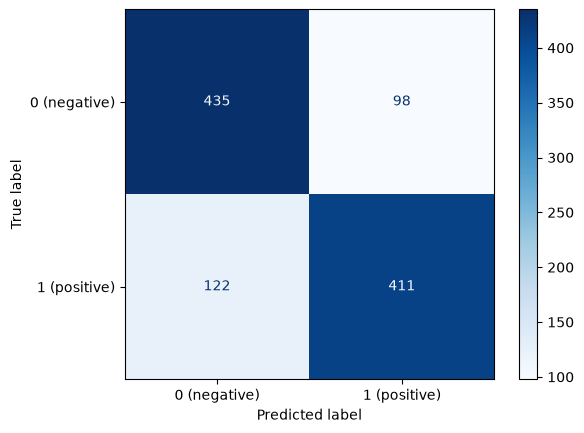

In [7]:
label_order = np.sort(np.array(list(expected_labels)))
macro_f1 = f1_score(y_test, test_predictions, average="macro")
cm = confusion_matrix(y_test, test_predictions, labels=label_order)

assert 0.0 <= macro_f1 <= 1.0
assert cm.shape == (2, 2)

print(f"Macro-F1: {macro_f1:.4f}")
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[f"{label} ({'negative' if label == 0 else 'positive'})" for label in label_order],
).plot(cmap="Blues", values_format="d")

## Model Performance

**Macro-F1:** 0.7935  
**Negative reviews:** 435 correct, 98 predicted as positive  
**Positive reviews:** 411 correct, 122 predicted as negative